In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="progression")

# Check for missing values
print(X.isnull().sum())

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


 Explanation:

No missing values in this dataset, but we checked anyway.

StandardScaler ensures all features are on the same scale, which is crucial for ANN training.

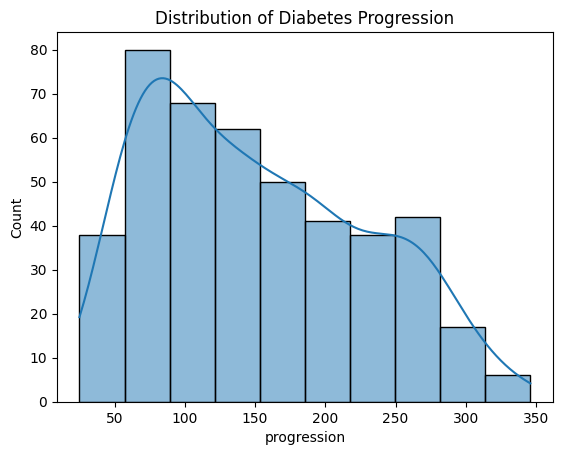

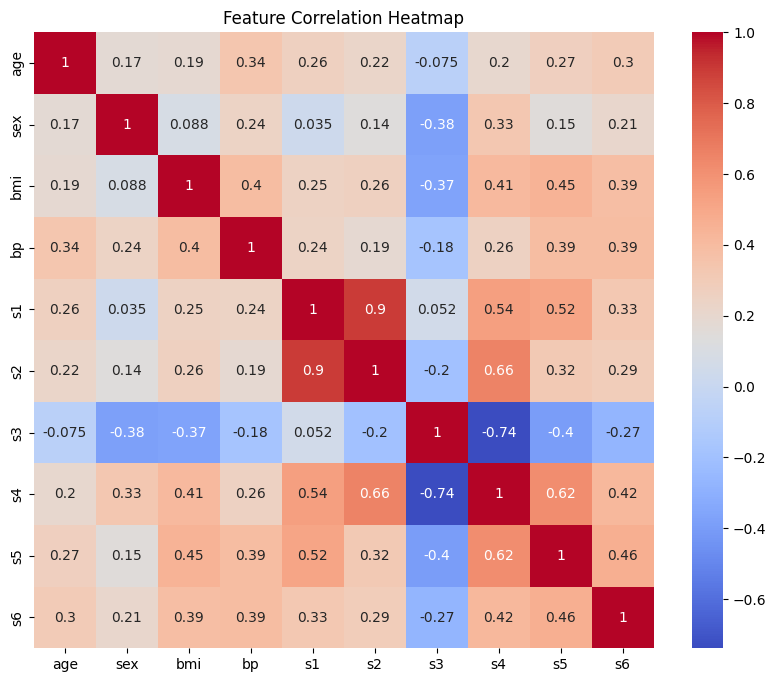

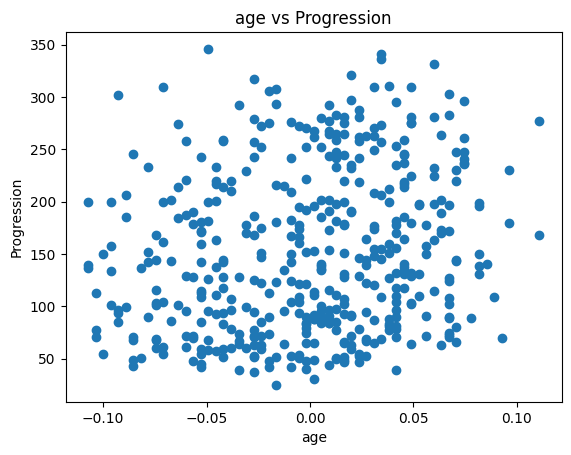

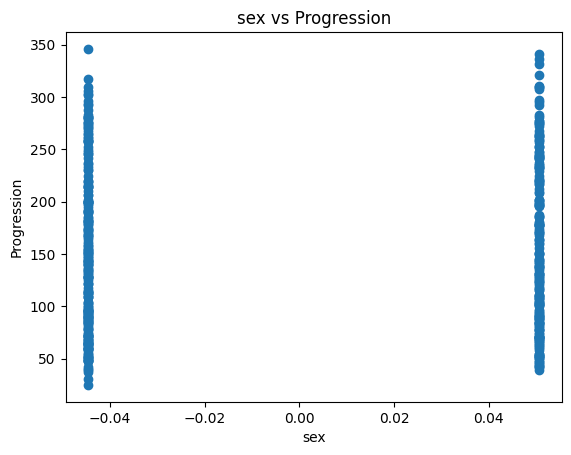

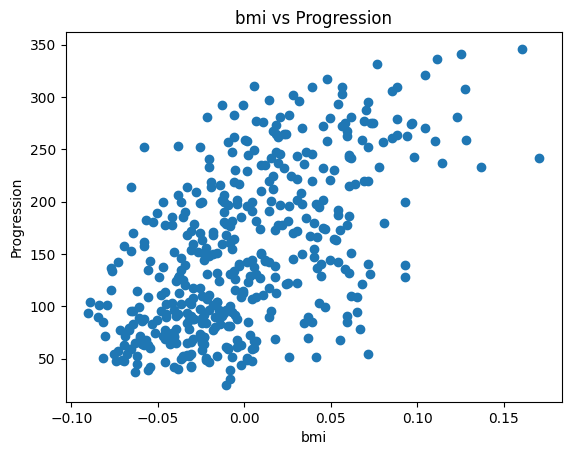

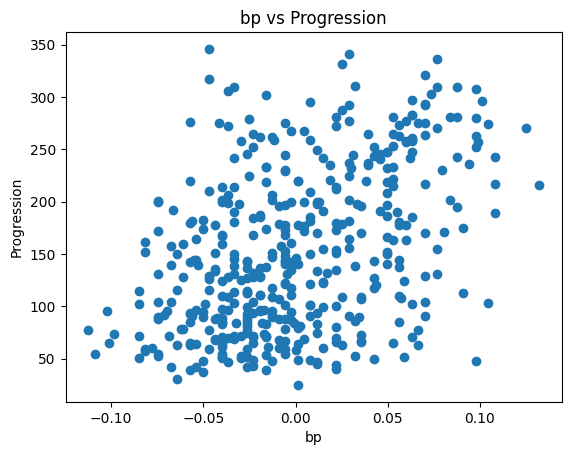

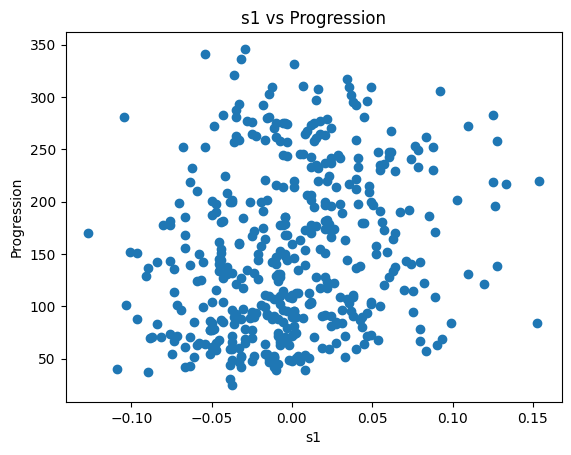

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="progression")

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Distribution of target variable
sns.histplot(y, kde=True)
plt.title("Distribution of Diabetes Progression")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_scaled, columns=diabetes.feature_names).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature vs target scatterplots
for col in diabetes.feature_names[:5]:  # show first 5 for brevity
    plt.scatter(X[col], y)
    plt.xlabel(col)
    plt.ylabel("Progression")
    plt.title(f"{col} vs Progression")
    plt.show()

Explanation:

Histogram shows target distribution.

Heatmap reveals relationships among features.

Scatterplots show how individual features relate to progression.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ANN architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # regression output
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Explanation:

Input layer = 10 features.

Hidden layers use ReLU.

Output layer is linear since this is regression.

In [7]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=0)

Explanation:

Loss = MSE (standard for regression).

Optimizer = Adam (efficient and widely used).

Trained for 100 epochs.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Mean Squared Error: 3037.483379204155
R2 Score: 0.4266899999505295


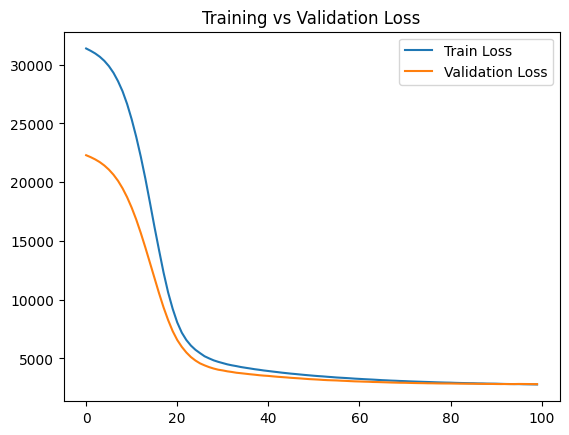

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Improved MSE: 3830.8761445478053
Improved R2: 0.27694103030922246


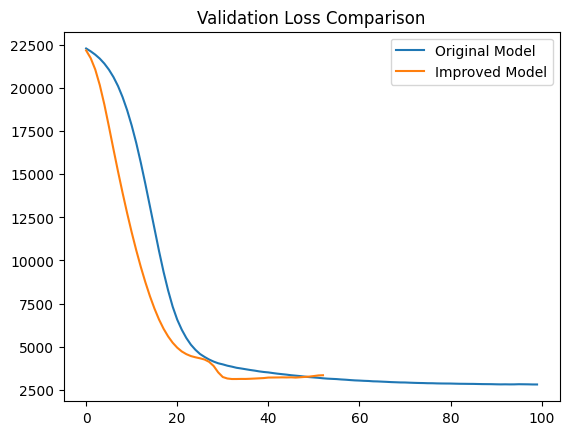

In [11]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# Improved ANN architecture
model_improved = Sequential([
    Dense(128, activation='relu', input_shape=(X_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# Compile with smaller learning rate
model_improved.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                       loss='mse', metrics=['mae'])

# EarlyStopping to avoid overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train improved model
history_improved = model_improved.fit(X_train, y_train, validation_split=0.2,
                                      epochs=200, batch_size=32,
                                      callbacks=[early_stop], verbose=0)

# Evaluate improved model
y_pred_improved = model_improved.predict(X_test)
mse_improved = mean_squared_error(y_test, y_pred_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print("Improved MSE:", mse_improved)
print("Improved R2:", r2_improved)

# Compare validation loss curves
plt.plot(history.history['val_loss'], label='Original Model')
plt.plot(history_improved.history['val_loss'], label='Improved Model')
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()


In [12]:
mse_original = mse
r2_original = r2


results = pd.DataFrame({
    "Model": ["Original ANN", "Improved ANN"],
    "Mean Squared Error (MSE)": [mse_original, mse_improved],
    "R² Score": [r2_original, r2_improved]
})

print(results)


          Model  Mean Squared Error (MSE)  R² Score
0  Original ANN               3037.483379  0.426690
1  Improved ANN               3830.876145  0.276941
